In [1]:
import pandas as pd
%matplotlib inline

In [2]:
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings('ignore')

In [3]:
# df = pd.read_csv('sales.csv')
df = pd.read_csv('sales.csv')

In [4]:
df.head()

,cost,price,weight,purchase_date,product_type,product_level,maker,ingredient,height,width,depth
0,$333k,"$300,492",3 Ton 90 Kg,Dec 19 2008,"Q,B",advanced,M14122,"IN732052,IN732053",2.76 meters,97 cm,26 cm
1,NaN,"$430,570",3 Ton 30 Kg,Sep 10 1997,"J,D",basic,NaN,"IN732054,IN732055,IN732056,IN732057,IN732058",2.67 meters,98 cm,26 cm
2,$270k,"$213,070",3 Ton 40 Kg,Sep 05 2001,"J,D",basic,NaN,"IN732054,IN732059,IN732060",3.0 meters,93 cm,24 cm
3,NaN,"$229,174",3 Ton 50 Kg,Dec 23 2016,U,advanced,M14123,"IN732061,IN732062,IN732063",2.5 meters,102 cm,27 cm
4,$97k,"$122,659",2 Ton 970 Kg,Jan 12 2000,"D,R",advanced,NaN,"IN732064,IN732065,IN732066",2.47 meters,101 cm,26 cm


# 1. Obtaining Datetime objects

<font color='red'>Question:</font> What is the type of **purchase_date**?

In [5]:
type(df.purchase_date[2])

str

In [6]:
# need to index !!!
type(df.purchase_date)

pandas.core.series.Series

In [7]:
# dtype is not specific enough
df['purchase_date'].dtype

dtype('O')

<font color='red'>Assignment:</font> Use **pandas.to_datetime** to **transform df.purchase_date** in to a series of datetime object and assign it to a variable **purchase_date**.

In [8]:
purchase_date = pd.to_datetime(df.purchase_date)
purchase_date

0      2008-12-19
1      1997-09-10
2      2001-09-05
3      2016-12-23
4      2000-01-12
          ...    
3192   2016-11-25
3193   2007-05-25
3194   2016-12-16
3195   2002-04-12
3196   2003-06-13
Name: purchase_date, Length: 3197, dtype: datetime64[ns]

<font color='red'>Assignment:</font> What is the earliest date in the datetime series.

In [9]:
sorted(purchase_date)[0]

Timestamp('1996-08-09 00:00:00')

In [10]:
purchase_date

0      2008-12-19
1      1997-09-10
2      2001-09-05
3      2016-12-23
4      2000-01-12
          ...    
3192   2016-11-25
3193   2007-05-25
3194   2016-12-16
3195   2002-04-12
3196   2003-06-13
Name: purchase_date, Length: 3197, dtype: datetime64[ns]

In [11]:
purchase_date.nsmallest(1)

1361   1996-08-09
Name: purchase_date, dtype: datetime64[ns]

In [12]:
purchase_date.min()

Timestamp('1996-08-09 00:00:00')

<font color='red'>Assignment:</font> What is the latest date in the datetime series.

In [13]:
sorted(purchase_date, reverse = True)[3]

Timestamp('2017-10-04 00:00:00')

In [14]:
purchase_date.nlargest(1)

3134   2017-10-06
Name: purchase_date, dtype: datetime64[ns]

In [15]:
purchase_date.max()

Timestamp('2017-10-06 00:00:00')

# 2. Time series

**Example:** Generate time series of **price**.

In [16]:
price = df.price.map(lambda x: x if type(x) == float else float(x.strip('$').replace(',', '')))

https://towardsdatascience.com/introduction-to-pandas-apply-applymap-and-map-5d3e044e93ff

In [17]:
price.head()

0    300492.0
1    430570.0
2    213070.0
3    229174.0
4    122659.0
Name: price, dtype: float64

In [18]:
price.index = purchase_date

In [19]:
price.head()

purchase_date
2008-12-19    300492.0
1997-09-10    430570.0
2001-09-05    213070.0
2016-12-23    229174.0
2000-01-12    122659.0
Name: price, dtype: float64

**Example**: Visualize the time series.

<AxesSubplot:xlabel='purchase_date'>

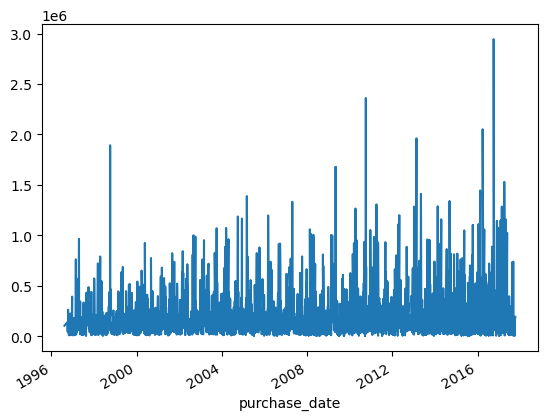

In [20]:
price.dropna().plot()

<font color='red'>Question:</font> Why do we need **dropna()** here?

In [21]:
price.isnull().sum()

11

### Becuase 'price' column has 11 NaN entries, which can not be plotted.

# 3. Time Series Aggregation

## 3.1 Resample

**Example**: Get montly counts of purchase events.

##### <font color='red'>Question:</font> why no dropna here?

<AxesSubplot:title={'center':'Monthly Counts'}, xlabel='purchase_date'>

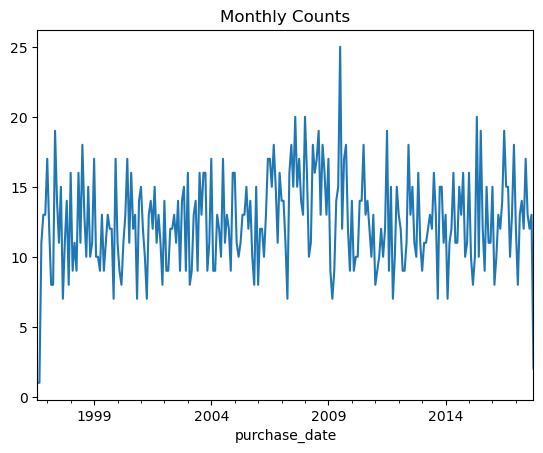

In [22]:
price.resample('M').count().plot(title='Monthly Counts')

In [23]:
price.sort_index()

purchase_date
1996-08-09    103343.0
1996-09-27    138381.0
1996-10-04     45701.0
1996-10-11    262119.0
1996-10-11    126383.0
                ...   
2017-10-04         NaN
2017-10-04         NaN
2017-10-04    174400.0
2017-10-06    192231.0
NaT                NaN
Name: price, Length: 3197, dtype: float64

In [24]:
# resample will sort by default
price.resample('D').count()

purchase_date
1996-08-09    1
1996-08-10    0
1996-08-11    0
1996-08-12    0
1996-08-13    0
             ..
2017-10-02    0
2017-10-03    0
2017-10-04    1
2017-10-05    0
2017-10-06    1
Name: price, Length: 7729, dtype: int64

<font color='red'>Assignment:</font> Get monthly price mean and median, respectively.

In [25]:
price.resample("M").mean()

purchase_date
1996-08-31    103343.000000
1996-09-30    138381.000000
1996-10-31    105156.818182
1996-11-30     76611.153846
1996-12-31     94739.615385
                  ...      
2017-06-30     93203.647059
2017-07-31    140474.307692
2017-08-31    217683.000000
2017-09-30    117562.153846
2017-10-31    183315.500000
Name: price, Length: 255, dtype: float64

<AxesSubplot:title={'center':'Montly Price Mean'}, xlabel='purchase_date'>

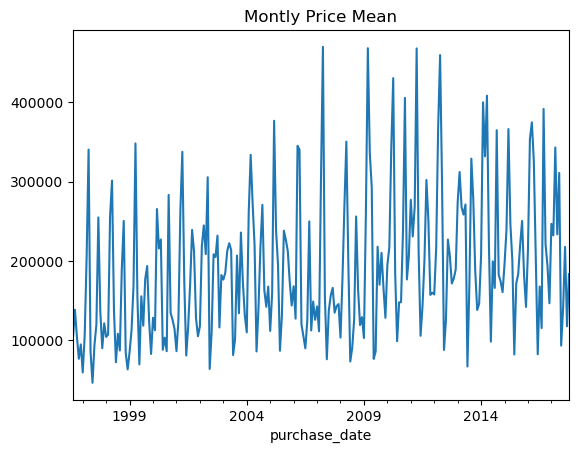

In [26]:
# price.resample('M').mean()
price.resample("M").mean().plot(title="Montly Price Mean")

<AxesSubplot:title={'center':'Montly Price Median'}, xlabel='purchase_date'>

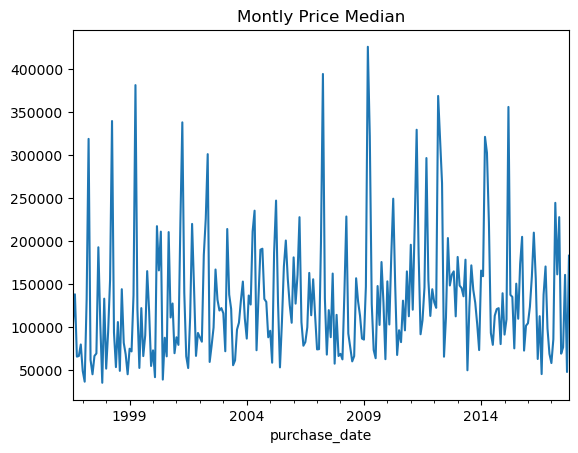

In [27]:
# price.resample('M').median()
price.resample("M").median().plot(title="Montly Price Median")

<font color='red'>Assignment:</font> Get bi-weekly price mean and median, respectively.

<AxesSubplot:title={'center':'Bi-weekly Price Mean'}, xlabel='purchase_date'>

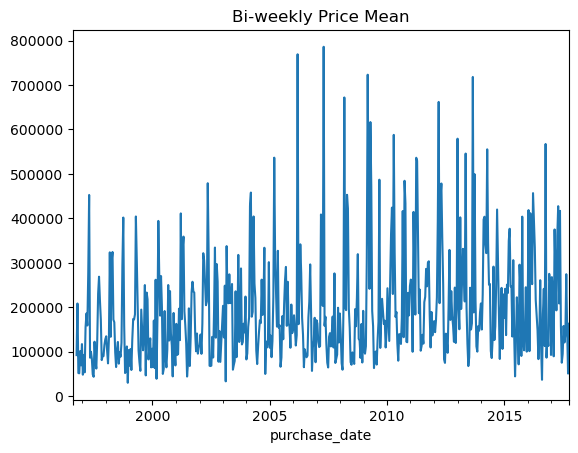

In [28]:
# price.resample('2W').mean()
price.resample("2W").mean().plot(title="Bi-weekly Price Mean")

In [29]:
price.resample("2W").median()

purchase_date
1996-08-11    103343.0
1996-08-25         NaN
1996-09-08         NaN
1996-09-22         NaN
1996-10-06     92041.0
                ...   
2017-08-13    113128.0
2017-08-27    213864.0
2017-09-10     48057.0
2017-09-24     11656.0
2017-10-08    179167.0
Name: price, Length: 553, dtype: float64

<AxesSubplot:title={'center':'Bi-weekly Price Median'}, xlabel='purchase_date'>

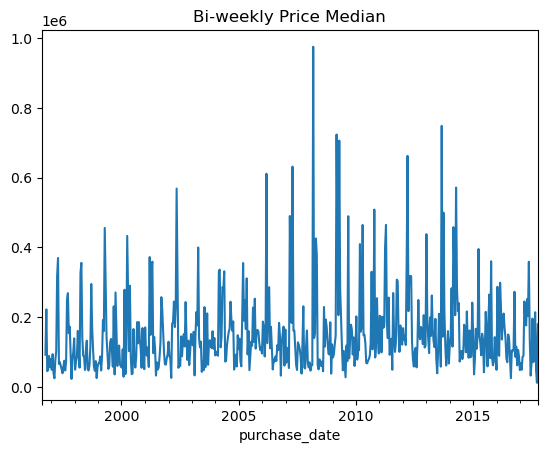

In [30]:
# price.resample('2W').median()
price.resample("2W").median().plot(title="Bi-weekly Price Median")

In [31]:
# bi-weekly is different from semi-month
price.resample('SM').mean()

purchase_date
1996-07-31    103343.000000
1996-08-15              NaN
1996-08-31              NaN
1996-09-15    138381.000000
1996-09-30    175711.000000
                  ...      
2017-07-31    138621.200000
2017-08-15    274155.714286
2017-08-31    148914.142857
2017-09-15     80984.833333
2017-09-30    183315.500000
Name: price, Length: 509, dtype: float64

In [32]:
# bi-weekly is different from semi-month
price.resample('14D').mean()

purchase_date
1996-08-09    103343.000000
1996-08-23              NaN
1996-09-06              NaN
1996-09-20    138381.000000
1996-10-04    175711.000000
                  ...      
2017-08-11    385915.750000
2017-08-25    138948.909091
2017-09-08     11656.000000
2017-09-22    127399.400000
2017-10-06    192231.000000
Name: price, Length: 553, dtype: float64

https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries-offset-aliases

<font color='red'>Assignment:</font> Get monthly **profit** mean and median, respectively.

In [33]:
cost = df.cost.map(lambda x: x if type(x) == float else 1000*float(x.strip('$').strip('k')))

In [34]:
cost.index = purchase_date

In [35]:
profit = price - cost

In [36]:
profit.resample('M').mean()

purchase_date
1996-08-31             NaN
1996-09-30             NaN
1996-10-31   -95299.000000
1996-11-30    53287.000000
1996-12-31    66760.000000
                  ...     
2017-06-30    11728.363636
2017-07-31    10765.300000
2017-08-31    65528.444444
2017-09-30     7084.500000
2017-10-31   -75184.500000
Length: 255, dtype: float64

In [37]:
profit.resample('M').median()

purchase_date
1996-08-31        NaN
1996-09-30        NaN
1996-10-31   -95299.0
1996-11-30    53287.0
1996-12-31    66760.0
               ...   
2017-06-30   -23867.0
2017-07-31    17397.5
2017-08-31    82128.0
2017-09-30    -1756.5
2017-10-31   -75184.5
Length: 255, dtype: float64

##### <font color='red'>Question:</font> how about the missing? Should I fillna in price and cost before calculating the profit?

In [38]:
# fillna in price and cost, then calculate profit
profit_fillna = price.fillna(price.mean()) - cost.fillna(cost.mean())
profit_fillna


purchase_date
2008-12-19    -32508.000000
1997-09-10    261337.148014
2001-09-05    -56930.000000
2016-12-23     59941.148014
2000-01-12     25659.000000
                  ...      
2016-11-25    -75883.851986
2007-05-25   -128848.851986
2016-12-16    905611.148014
2002-04-12     11931.000000
2003-06-13    -83630.000000
Length: 3197, dtype: float64

In [39]:
price[(price.index>='1996-12')&(price.index<'1997-01')].sort_index()

purchase_date
1996-12-06     30358.0
1996-12-06     20648.0
1996-12-06    104481.0
1996-12-06     11583.0
1996-12-13     83726.0
1996-12-13    163218.0
1996-12-20     80039.0
1996-12-20     32051.0
1996-12-20    105676.0
1996-12-20     10321.0
1996-12-20    392466.0
1996-12-27     16612.0
1996-12-27    180436.0
Name: price, dtype: float64

In [40]:
cost[(cost.index>='1996-12')&(cost.index<'1997-01')].sort_index()

purchase_date
1996-12-06        NaN
1996-12-06        NaN
1996-12-06    26000.0
1996-12-06        NaN
1996-12-13        NaN
1996-12-13        NaN
1996-12-20    25000.0
1996-12-20        NaN
1996-12-20        NaN
1996-12-20        NaN
1996-12-20        NaN
1996-12-27        NaN
1996-12-27        NaN
Name: cost, dtype: float64

In [41]:
profit[(profit.index>='1996-12')&(profit.index<'1997-01')].sort_index()

purchase_date
1996-12-06        NaN
1996-12-06        NaN
1996-12-06    78481.0
1996-12-06        NaN
1996-12-13        NaN
1996-12-13        NaN
1996-12-20    55039.0
1996-12-20        NaN
1996-12-20        NaN
1996-12-20        NaN
1996-12-20        NaN
1996-12-27        NaN
1996-12-27        NaN
dtype: float64

In [42]:
profit.index>='1996-12'

array([ True,  True,  True, ...,  True,  True,  True])

In [43]:
# nan in cost is filled by a large value
profit_fillna[(profit_fillna.index>='1996-12')&(profit_fillna.index<'1997-01')].sort_index()

purchase_date
1996-12-06   -138874.851986
1996-12-06   -148584.851986
1996-12-06     78481.000000
1996-12-06   -157649.851986
1996-12-13    -85506.851986
1996-12-13     -6014.851986
1996-12-20     55039.000000
1996-12-20   -137181.851986
1996-12-20    -63556.851986
1996-12-20   -158911.851986
1996-12-20    223233.148014
1996-12-27   -152620.851986
1996-12-27     11203.148014
dtype: float64

##### You can fillna here, but needs to be more careful.

## 3.2 Rolling

\<font color='red'>Assignment:</font> Get seven-day rolling average of profit.

**what is rolling (moving) average?**

**two steps:**
1. list the profit of each day, ordered and aggregated (could have multiple sales in one day) - resample function
2. calculate rolling average - rolling function

In [44]:
profit.sort_index()

purchase_date
1996-08-09         NaN
1996-09-27         NaN
1996-10-04    -95299.0
1996-10-11         NaN
1996-10-11         NaN
                ...   
2017-10-04         NaN
2017-10-04         NaN
2017-10-04   -220600.0
2017-10-06     70231.0
NaT                NaN
Length: 3197, dtype: float64

In [45]:
# multiple sales single day - 2017-09-29
profit.sort_index().dropna()

purchase_date
1996-10-04    -95299.0
1996-11-01     21886.0
1996-11-29     84688.0
1996-12-06     78481.0
1996-12-20     55039.0
                ...   
2017-09-22     30775.0
2017-09-29    105934.0
2017-09-29    -15842.0
2017-10-04   -220600.0
2017-10-06     70231.0
Length: 2211, dtype: float64

In [46]:
# if no aggregation, will be multiple values for the same day - 2017-09-29
profit.sort_index().dropna().rolling('7D').sum()

purchase_date
1996-10-04    -95299.0
1996-11-01     21886.0
1996-11-29     84688.0
1996-12-06     78481.0
1996-12-20     55039.0
                ...   
2017-09-22     30775.0
2017-09-29    105934.0
2017-09-29     90092.0
2017-10-04   -130508.0
2017-10-06   -150369.0
Length: 2211, dtype: float64

In [47]:
profit.sort_index().dropna().rolling('7D').mean()


purchase_date
1996-10-04    -95299.000000
1996-11-01     21886.000000
1996-11-29     84688.000000
1996-12-06     78481.000000
1996-12-20     55039.000000
                  ...      
2017-09-22     30775.000000
2017-09-29    105934.000000
2017-09-29     45046.000000
2017-10-04    -43502.666667
2017-10-06    -75184.500000
Length: 2211, dtype: float64

In [48]:
profit.sort_index().dropna().resample('7D').mean()

purchase_date
1996-10-04   -95299.000000
1996-10-11             NaN
1996-10-18             NaN
1996-10-25             NaN
1996-11-01    21886.000000
                  ...     
2017-09-08             NaN
2017-09-15     -203.000000
2017-09-22    30775.000000
2017-09-29   -43502.666667
2017-10-06    70231.000000
Freq: 7D, Length: 1097, dtype: float64

In [49]:
profit.groupby(level=0).sum()


purchase_date
1996-08-09         0.0
1996-09-27         0.0
1996-10-04    -95299.0
1996-10-11         0.0
1996-10-25         0.0
                ...   
2017-09-15      -203.0
2017-09-22     30775.0
2017-09-29     90092.0
2017-10-04   -220600.0
2017-10-06     70231.0
Length: 1278, dtype: float64

In [50]:
# must include every single day, resample, rather than groupby
profit.groupby(level=0).sum().rolling('7D').mean()


purchase_date
1996-08-09        0.0
1996-09-27        0.0
1996-10-04   -95299.0
1996-10-11        0.0
1996-10-25        0.0
               ...   
2017-09-15     -203.0
2017-09-22    30775.0
2017-09-29    90092.0
2017-10-04   -65254.0
2017-10-06   -75184.5
Length: 1278, dtype: float64

In [51]:
# the '-75184.5' is /2 not /7 of the last 7 days
profit.groupby(level=0).sum()

purchase_date
1996-08-09         0.0
1996-09-27         0.0
1996-10-04    -95299.0
1996-10-11         0.0
1996-10-25         0.0
                ...   
2017-09-15      -203.0
2017-09-22     30775.0
2017-09-29     90092.0
2017-10-04   -220600.0
2017-10-06     70231.0
Length: 1278, dtype: float64

In [52]:
# list the daily profit, ordered and aggregated (sum, not mean!!!)
profit.resample('D').sum()

purchase_date
1996-08-09         0.0
1996-08-10         0.0
1996-08-11         0.0
1996-08-12         0.0
1996-08-13         0.0
                ...   
2017-10-02         0.0
2017-10-03         0.0
2017-10-04   -220600.0
2017-10-05         0.0
2017-10-06     70231.0
Length: 7729, dtype: float64

In [53]:
price.aggregate(['median','mean'])

median    110522.500000
mean      182317.636849
Name: price, dtype: float64

In [54]:
price.mean()

182317.63684871313

In [55]:
price.agg('mean')

182317.63684871313

In [56]:
price.mean()

182317.63684871313

In [57]:
profit.resample('D').sum()

purchase_date
1996-08-09         0.0
1996-08-10         0.0
1996-08-11         0.0
1996-08-12         0.0
1996-08-13         0.0
                ...   
2017-10-02         0.0
2017-10-03         0.0
2017-10-04   -220600.0
2017-10-05         0.0
2017-10-06     70231.0
Length: 7729, dtype: float64

In [58]:
# window = 7
profit.resample('D').sum().rolling(7).mean()

purchase_date
1996-08-09             NaN
1996-08-10             NaN
1996-08-11             NaN
1996-08-12             NaN
1996-08-13             NaN
                  ...     
2017-10-02    12870.285714
2017-10-03    12870.285714
2017-10-04   -18644.000000
2017-10-05   -18644.000000
2017-10-06   -21481.285714
Length: 7729, dtype: float64

In [59]:
# window = '7D'
profit.resample('D').sum().rolling('7D').mean()

purchase_date
1996-08-09        0.000000
1996-08-10        0.000000
1996-08-11        0.000000
1996-08-12        0.000000
1996-08-13        0.000000
                  ...     
2017-10-02    12870.285714
2017-10-03    12870.285714
2017-10-04   -18644.000000
2017-10-05   -18644.000000
2017-10-06   -21481.285714
Length: 7729, dtype: float64

In [60]:
The reason why rolling(7) and rolling('7D') produce different head rows is because they represent different rolling window sizes.

rolling(7) represents a rolling window of 7 elements, which means that it takes the average of the current element and the previous 6 elements. In other words, it calculates a rolling window of 7 days by default, assuming that the data has a daily frequency.

On the other hand, rolling('7D') represents a rolling window of 7 days, regardless of the frequency of the data. This means that it takes the average of the current element and the previous elements within a 7-day time interval. If the frequency of the data is daily, this will be equivalent to rolling(7), but if the frequency is different, then the window size will adjust accordingly.

So, if you apply both methods to the same DataFrame and compare the head rows, you may see different results because they represent different rolling window sizes. The first few rows will differ because rolling(7) starts from the 7th element, while rolling('7D') starts from the first element that has 6 previous elements within a 7-day time interval.

In summary, the choice between rolling(7) and rolling('7D') depends on the specific needs of your analysis. If you want a fixed window size in terms of the number of elements, then you can use rolling(7). If you want a fixed window size in terms of time intervals, then you can use rolling('7D').

SyntaxError: invalid syntax (1224804950.py, line 1)

##### <font color='red'>Question:</font> why rolling 7 and '7D' have different head rows?

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html

**min_periods**

## 3.3 Cumulative

<font color='red'>Assignment:</font> Get cumulative sum of profit.

**Tips**
1. cumulative sum is not sum
2. don't forgot to resample first (otherwise duplicate records of the same day)

In [61]:
profit.resample('D').sum().cumsum()

purchase_date
1996-08-09            0.0
1996-08-10            0.0
1996-08-11            0.0
1996-08-12            0.0
1996-08-13            0.0
                 ...     
2017-10-02    110569758.0
2017-10-03    110569758.0
2017-10-04    110349158.0
2017-10-05    110349158.0
2017-10-06    110419389.0
Length: 7729, dtype: float64

<AxesSubplot:title={'center':'Cumulative Sum Profit'}, xlabel='purchase_date'>

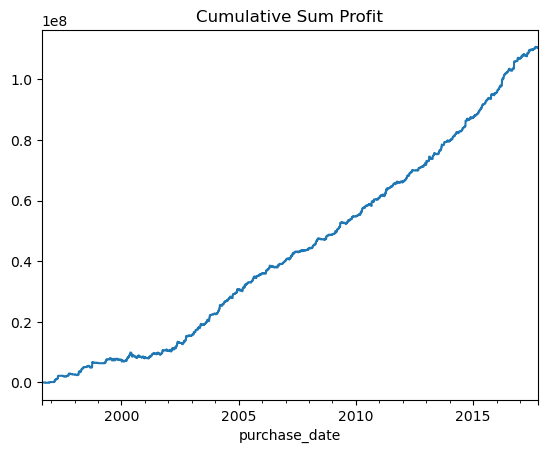

In [62]:
profit.resample("D").sum().cumsum().plot(title="Cumulative Sum Profit")

<AxesSubplot:title={'center':'Cumulative Sum Profit'}, xlabel='purchase_date'>

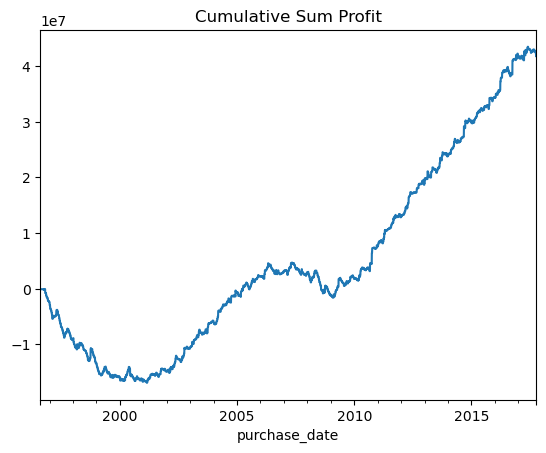

In [63]:
# profit with price and cost filled nan, cost over-estimated
profit_fillna.resample("D").sum().cumsum().plot(title="Cumulative Sum Profit")

##### This is the so-called 'business sense'

## 3.4 Time features

**Example:** Get weekday from the datetime series.

In [64]:
weekday = purchase_date.dt.weekday

In [83]:
month = purchase_date.dt.month

In [84]:
month.head()

0    12.0
1     9.0
2     9.0
3    12.0
4     1.0
Name: purchase_date, dtype: float64

In [65]:
weekday.head() # Monday=0, Sunday=6

0    4.0
1    2.0
2    2.0
3    4.0
4    2.0
Name: purchase_date, dtype: float64

**Example:** Get averaged price for each weekday.

In [66]:
df_tmp = pd.DataFrame({'price': price.values, 'weekday': weekday})

In [86]:
df_m = pd.DataFrame({'price': price.values, 'month': month})

In [87]:
df_m.head()

,price,month
0,300492.0,12.0
1,430570.0,9.0
2,213070.0,9.0
3,229174.0,12.0
4,122659.0,1.0


In [67]:
df_tmp.head()

,price,weekday
0,300492.0,4.0
1,430570.0,2.0
2,213070.0,2.0
3,229174.0,4.0
4,122659.0,2.0


<font color='red'>Question:</font> Why do we need **.values** for **price** here?

### It returns the Series as an array ???

In [68]:
pd.DataFrame({'price': price, 'weekday': weekday})

ValueError: cannot reindex on an axis with duplicate labels

In [69]:
weekday

0       4.0
1       2.0
2       2.0
3       4.0
4       2.0
       ... 
3192    4.0
3193    4.0
3194    4.0
3195    4.0
3196    4.0
Name: purchase_date, Length: 3197, dtype: float64

In [88]:
month

0       12.0
1        9.0
2        9.0
3       12.0
4        1.0
        ... 
3192    11.0
3193     5.0
3194    12.0
3195     4.0
3196     6.0
Name: purchase_date, Length: 3197, dtype: float64

In [70]:
price

purchase_date
2008-12-19     300492.0
1997-09-10     430570.0
2001-09-05     213070.0
2016-12-23     229174.0
2000-01-12     122659.0
                ...    
2016-11-25      93349.0
2007-05-25      40384.0
2016-12-16    1074844.0
2002-04-12      55931.0
2003-06-13      44370.0
Name: price, Length: 3197, dtype: float64

In [71]:
price.index.duplicated().sum()

1918

In [72]:
price.sort_index()

purchase_date
1996-08-09    103343.0
1996-09-27    138381.0
1996-10-04     45701.0
1996-10-11    262119.0
1996-10-11    126383.0
                ...   
2017-10-04         NaN
2017-10-04         NaN
2017-10-04    174400.0
2017-10-06    192231.0
NaT                NaN
Name: price, Length: 3197, dtype: float64

In [89]:
m = month.copy() # can I do without .copy()? object v.s. reference (view)
m.index = purchase_date
m

purchase_date
2008-12-19    12.0
1997-09-10     9.0
2001-09-05     9.0
2016-12-23    12.0
2000-01-12     1.0
              ... 
2016-11-25    11.0
2007-05-25     5.0
2016-12-16    12.0
2002-04-12     4.0
2003-06-13     6.0
Name: purchase_date, Length: 3197, dtype: float64

In [73]:
# another sulotion
temp = weekday.copy() # can I do without .copy()? object v.s. reference (view)
temp.index = purchase_date
temp

purchase_date
2008-12-19    4.0
1997-09-10    2.0
2001-09-05    2.0
2016-12-23    4.0
2000-01-12    2.0
             ... 
2016-11-25    4.0
2007-05-25    4.0
2016-12-16    4.0
2002-04-12    4.0
2003-06-13    4.0
Name: purchase_date, Length: 3197, dtype: float64

https://www.dataquest.io/blog/settingwithcopywarning/

In [92]:
pd.DataFrame({'price': price, 'month': m}).head()

,price,month
purchase_date,,
2008-12-19,300492.0,12.0
1997-09-10,430570.0,9.0
2001-09-05,213070.0,9.0
2016-12-23,229174.0,12.0
2000-01-12,122659.0,1.0


In [74]:
pd.DataFrame({'price': price, 'weekday': temp}).head()

,price,weekday
purchase_date,,
2008-12-19,300492.0,4.0
1997-09-10,430570.0,2.0
2001-09-05,213070.0,2.0
2016-12-23,229174.0,4.0
2000-01-12,122659.0,2.0


In [ ]:
pd.DataFrame({'price': price, 'weekday': temp}).head()

https://pandas.pydata.org/pandas-docs/dev/user_guide/duplicates.html

<AxesSubplot:xlabel='month'>

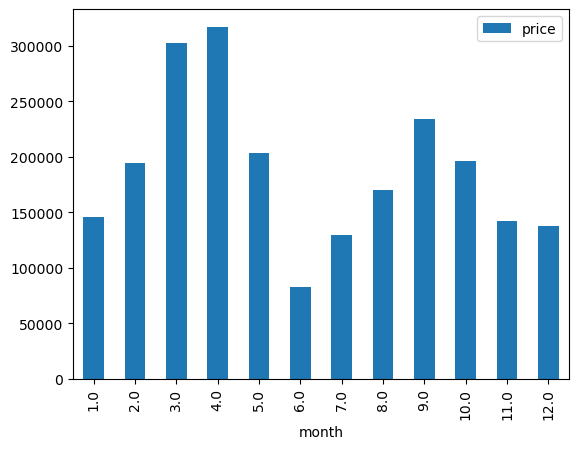

In [94]:
df_m.groupby('month').mean().plot(kind='bar')

<AxesSubplot:xlabel='weekday'>

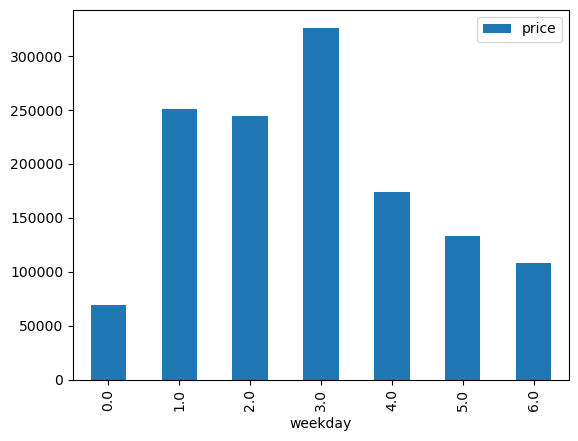

In [75]:
# very useful plot for time series data analysis
df_tmp.groupby('weekday').mean().plot(kind='bar')

<font color='red'>Assignment:</font> Get profit median for each month.

##### some of you didn't get the question

In [82]:
price_month= pd.DataFrame({'price': price, 'month': purchase_date.dt.month})


ValueError: cannot reindex on an axis with duplicate labels

In [76]:
profit_month= pd.DataFrame({'profit': profit.values, 'month': purchase_date.dt.month})


In [77]:
profit_month.head()

,profit,month
0,-32508.0,12.0
1,NaN,9.0
2,-56930.0,9.0
3,NaN,12.0
4,25659.0,1.0


<AxesSubplot:xlabel='month'>

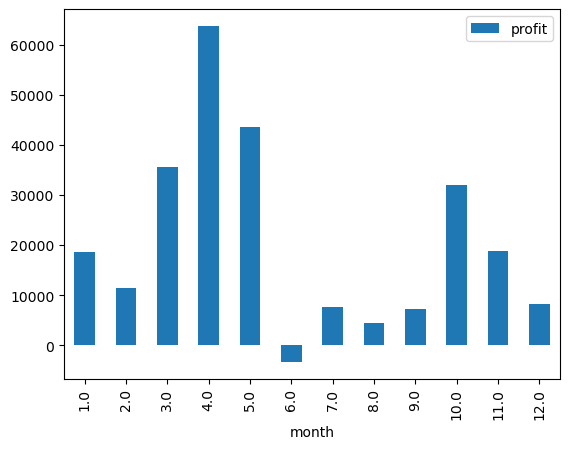

In [78]:
profit_month.groupby('month').median().plot(kind = 'bar')

* name a few time series data?

1. stock price
2. sensor